<a href="https://colab.research.google.com/github/divya223352/AI-ML-internship-task-10/blob/main/Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset structure: X shape (1797, 64), y shape (1797,)


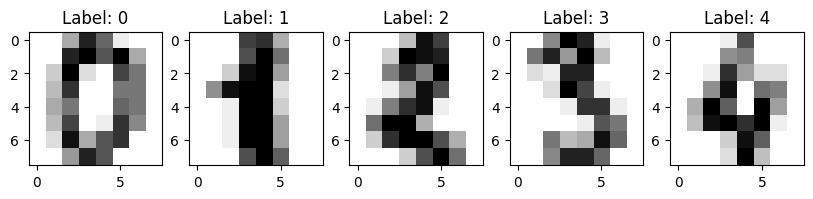

Accuracy for K=3: 0.9694
Accuracy for K=5: 0.9750
Accuracy for K=7: 0.9722
Accuracy for K=9: 0.9722


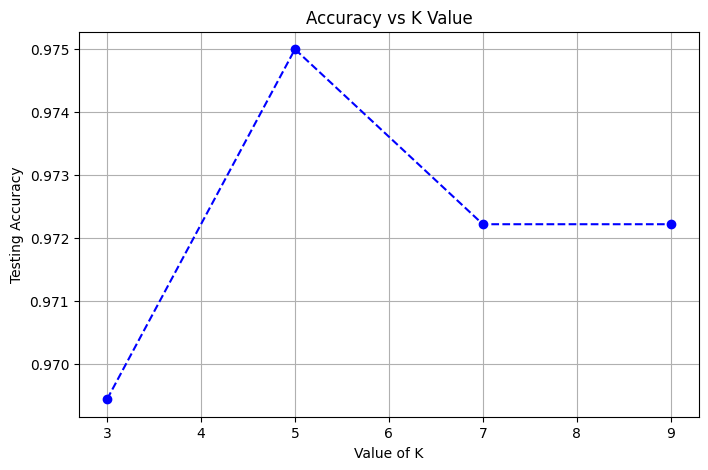

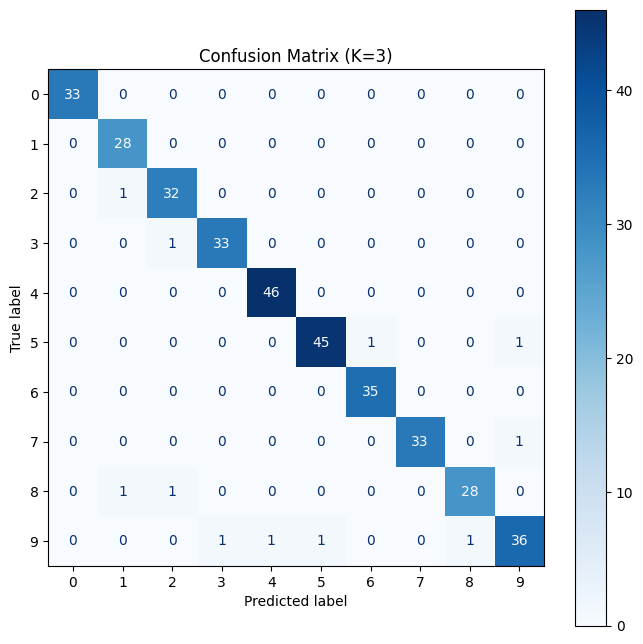

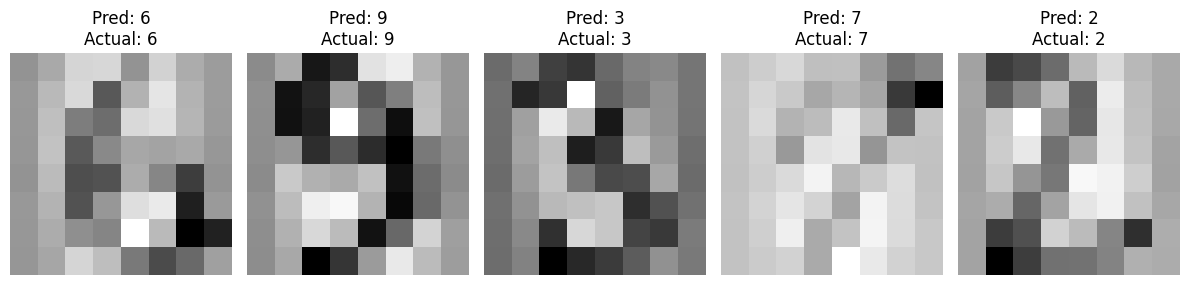

In [11]:
# 1. Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# 2. Load the digits dataset
digits = datasets.load_digits()
X = digits.data
y = digits.target
print(f"Dataset structure: X shape {X.shape}, y shape {y.shape}")

# 3. Visualize a few digit images
plt.figure(figsize=(10, 4))
for index, (image, label) in enumerate(zip(digits.images[:5], digits.target[:5])):
    plt.subplot(1, 5, index + 1)
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f'Label: {label}')
plt.show()

# 4. Split dataset into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Apply feature scaling
# KNN uses distance, so scaling ensures all features contribute equally
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Try multiple K values (3, 5, 7, 9) and store results
k_values = [3, 5, 7, 9]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Accuracy for K={k}: {acc:.4f}")

# 7. Plot Accuracy vs K graph
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='--', color='b')
plt.title('Accuracy vs K Value')
plt.xlabel('Value of K')
plt.ylabel('Testing Accuracy')
plt.grid(True)
plt.show()

# 8. Generate Confusion Matrix for the best K (let's use K=3)
best_knn = KNeighborsClassifier(n_neighbors=3)
best_knn.fit(X_train, y_train)
y_pred_best = best_knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix (K=3)")
plt.show()

# 9. Display 5 test images with predicted labels
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # We must reshape the flat data back to 8x8 to visualize
    plt.imshow(X_test[i].reshape(8, 8), cmap=plt.cm.gray_r)
    plt.title(f"Pred: {y_pred_best[i]}\nActual: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

K-Nearest Neighbors (KNN) is a supervised learning algorithm used for classification. It works on a simple principle: "Tell me who your neighbors are, and I'll tell you who you are."
When you give the model a new image of a digit, it looks at the "K" closest examples in the training data. If most of those neighbors are the number "3", the model predicts "3".
2. Distance Calculation
The most common way KNN measures "closeness" is through Euclidean Distance. Mathematically, it is the straight-line distance between two points in space: